# Sentence Length Distribution


In [5]:
import math
import os
import sys
from typing import Dict, List

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
sys.path.append(os.path.abspath('..'))
from datasets import load_from_disk
from src.data_loader import FeedbackProcessor

/home/coronny/sentiment_analysis/.venv/lib/python3.13/site-packages/pyvi/ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [6]:
def compute_token_lengths(processor: FeedbackProcessor, split_data) -> List[int]:
    lengths = []
    for item in split_data:
        processed = processor.process_text(item["sentence"])
        lengths.append(len(processed.split()))
    return lengths


def summarize_lengths(lengths: List[int]) -> Dict[str, float]:
    arr = np.array(lengths)
    return {
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "p95": float(np.percentile(arr, 95)),
        "max": float(np.max(arr)),
    }




=== Sentence length statistics by split ===
Train: mean=9.62, median=7.00, p95=24.00, max=114
Val: mean=9.07, median=7.00, p95=23.00, max=123
Test: mean=9.56, median=7.00, p95=25.00, max=72

Full dataset: mean=9.55, median=7.00, p95=24.00, max=123
Train outlier check (> 60 tokens): 14 sentences
Sample train outlier (index=1235, length=64): thầy rất chăm chút và nhẹ nhàng với những sinh viên mà thầy quen biết , khi báo cáo thầy đều cho các bạn qua môn hoặc điểm rất là cao mặt dù thầy nói đồ án yêu cầu một người làm , tuy nhiên có nhóm hai thành viên cùng làm một đồ án và có hai nhóm có cùng một project như nhau , y chang code ( copy từ cùng nguồn internet ) thầy vẫn cho qua môn .
Proposed max_length for data_loader.py: 24
Saved figure to: /home/coronny/sentiment_analysis/reports/figure/01_eda/sentence_length_distributed.png


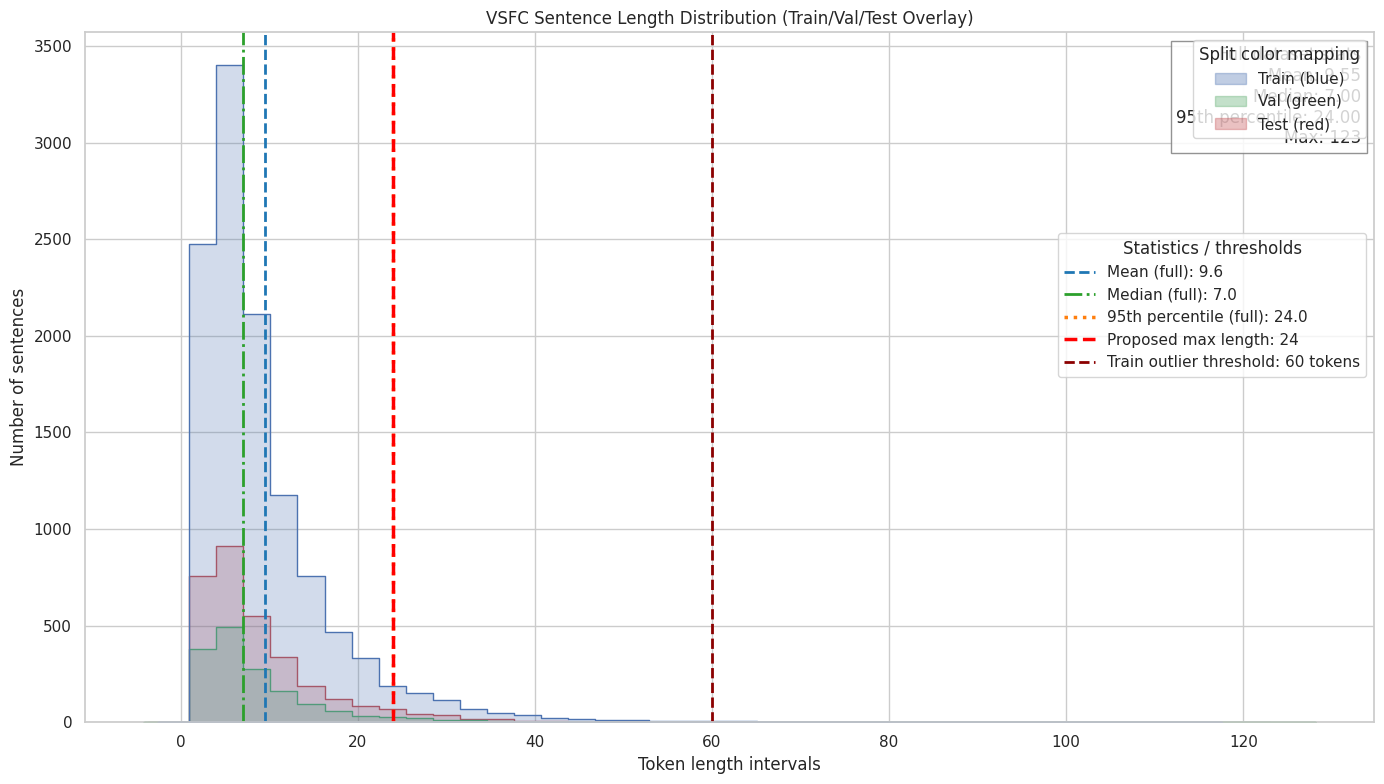

In [ ]:
def main() -> None:
    from pathlib import Path

    repo_root = Path.cwd().parent  # if notebook is in notebooks/
    dataset_path = repo_root / "datasets" / "vsfc"

    dataset = load_from_disk(dataset_path)
    processor = FeedbackProcessor(max_length=50, device="cpu")

    split_mapping = {
        "Train": dataset["train"],
        "Val": dataset["validation"],
        "Test": dataset["test"],
    }

    split_lengths: Dict[str, List[int]] = {}
    split_sentences: Dict[str, List[str]] = {}
    split_stats: Dict[str, Dict[str, float]] = {}

    for split_name, split_data in split_mapping.items():
        lengths = compute_token_lengths(processor, split_data)
        split_lengths[split_name] = lengths
        split_sentences[split_name] = [item["sentence"] for item in split_data]
        split_stats[split_name] = summarize_lengths(lengths)

    full_lengths = [l for lengths in split_lengths.values() for l in lengths]
    full_stats = summarize_lengths(full_lengths)
    proposed_max_length = int(math.ceil(full_stats["p95"]))

    df_all = pd.concat(
        [
            pd.DataFrame({"length": split_lengths["Train"], "set": "Train"}),
            pd.DataFrame({"length": split_lengths["Val"], "set": "Val"}),
            pd.DataFrame({"length": split_lengths["Test"], "set": "Test"}),
        ],
        ignore_index=True,
    )
    root_path = os.path.join(os.path.expanduser("~"), "sentiment_analysis")
    output_dir = os.path.join(root_path, "reports", "figure", "01_eda")
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, "sentence_length_distributed.png")

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 8))
    ax = plt.gca()
    split_palette = {"Train": "#4C72B0", "Val": "#55A868", "Test": "#C44E52"}

    sns.histplot(
        data=df_all,
        x="length",
        hue="set",
        bins=40,
        stat="count",
        common_norm=False,
        alpha=0.25,
        element="step",
        palette=split_palette,
        ax=ax,
    )
    sns.kdeplot(
        data=df_all,
        x="length",
        hue="set",
        fill=True,
        common_norm=False,
        palette=split_palette,
        alpha=0.2,
        linewidth=1.7,
        ax=ax,
    )

    mean_line = plt.axvline(
        x=full_stats["mean"],
        color="#1f77b4",
        linestyle="--",
        linewidth=2,
    )
    median_line = plt.axvline(
        x=full_stats["median"],
        color="#2ca02c",
        linestyle="-.",
        linewidth=2,
    )
    p95_line = plt.axvline(
        x=full_stats["p95"],
        color="#ff7f0e",
        linestyle=":",
        linewidth=2.5,
    )
    proposed_line = plt.axvline(
        x=proposed_max_length,
        color="red",
        linestyle="--",
        linewidth=2.5,
    )
    outlier_line = plt.axvline(
        x=60,
        color="#8B0000",
        linestyle="--",
        linewidth=2,
    )

    stats_text = (
        f"Full dataset stats\n"
        f"Mean: {full_stats['mean']:.2f}\n"
        f"Median: {full_stats['median']:.2f}\n"
        f"95th percentile: {full_stats['p95']:.2f}\n"
        f"Max: {int(full_stats['max'])}"
    )
    plt.text(
        0.99,
        0.98,
        stats_text,
        transform=plt.gca().transAxes,
        ha="right",
        va="top",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "gray"},
    )

    plt.title("VSFC Sentence Length Distribution (Train/Val/Test Overlay)")
    plt.xlabel("Token length intervals")
    plt.ylabel("Number of sentences")
    split_legend_handles = [
        Patch(facecolor=split_palette["Train"], edgecolor=split_palette["Train"], alpha=0.35, label="Train (blue)"),
        Patch(facecolor=split_palette["Val"], edgecolor=split_palette["Val"], alpha=0.35, label="Val (green)"),
        Patch(facecolor=split_palette["Test"], edgecolor=split_palette["Test"], alpha=0.35, label="Test (red)"),
    ]
    threshold_legend_handles = [
        Line2D([0], [0], color=mean_line.get_color(), linestyle=mean_line.get_linestyle(), linewidth=2,
               label=f"Mean (full): {full_stats['mean']:.1f}"),
        Line2D([0], [0], color=median_line.get_color(), linestyle=median_line.get_linestyle(), linewidth=2,
               label=f"Median (full): {full_stats['median']:.1f}"),
        Line2D([0], [0], color=p95_line.get_color(), linestyle=p95_line.get_linestyle(), linewidth=2.5,
               label=f"95th percentile (full): {full_stats['p95']:.1f}"),
        Line2D([0], [0], color=proposed_line.get_color(), linestyle=proposed_line.get_linestyle(), linewidth=2.5,
               label=f"Proposed max length: {proposed_max_length}"),
        Line2D([0], [0], color=outlier_line.get_color(), linestyle=outlier_line.get_linestyle(), linewidth=2,
               label="Train outlier threshold: 60 tokens"),
    ]
    legend_split = ax.legend(
        handles=split_legend_handles,
        title="Split color mapping",
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
    )
    ax.add_artist(legend_split)
    ax.legend(
        handles=threshold_legend_handles,
        title="Statistics / thresholds",
        loc="upper right",
        bbox_to_anchor=(1.0, 0.72),
    )
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

    print("=== Sentence length statistics by split ===")
    for split_name, stats in split_stats.items():
        print(
            f"{split_name}: mean={stats['mean']:.2f}, median={stats['median']:.2f}, "
            f"p95={stats['p95']:.2f}, max={int(stats['max'])}"
        )

    print(
        f"\nFull dataset: mean={full_stats['mean']:.2f}, median={full_stats['median']:.2f}, "
        f"p95={full_stats['p95']:.2f}, max={int(full_stats['max'])}"
    )
    train_outlier_threshold = 60
    train_outlier_idx = [
        idx for idx, length in enumerate(split_lengths["Train"]) if length > train_outlier_threshold
    ]
    print(
        f"Train outlier check (> {train_outlier_threshold} tokens): "
        f"{len(train_outlier_idx)} sentences"
    )
    if train_outlier_idx:
        sample_idx = train_outlier_idx[0]
        print(
            f"Sample train outlier (index={sample_idx}, "
            f"length={split_lengths['Train'][sample_idx]}): "
            f"{split_sentences['Train'][sample_idx]}"
        )
    print(f"Proposed max_length for data_loader.py: {proposed_max_length}")
    print(f"Saved figure to: {output_path}")
if __name__ == "__main__":
    main()

# Label Distribution

In [9]:
LABEL_MAP: Dict[int, str] = {
    0: "Negative",
    1: "Neutral",
    2: "Positive",
}


def build_label_dataframe(dataset) -> pd.DataFrame:
    records = []

    split_name_map = {
        "train": "Train",
        "validation": "Val",
        "test": "Test",
    }

    for split_key, split_name in split_name_map.items():
        split_df = dataset[split_key].to_pandas()
        label_counts = split_df["sentiment"].value_counts().to_dict()

        for label_id, label_name in LABEL_MAP.items():
            records.append(
                {
                    "split": split_name,
                    "label": label_name,
                    "count": int(label_counts.get(label_id, 0)),
                }
            )

    return pd.DataFrame(records)




=== Label distribution by split ===
label  Negative  Neutral  Positive
split                             
Test       1409      167      1590
Train      5325      458      5643
Val         705       73       805

Saved figure to: /home/coronny/sentiment_analysis/reports/figure/01_eda/label_distribution.png


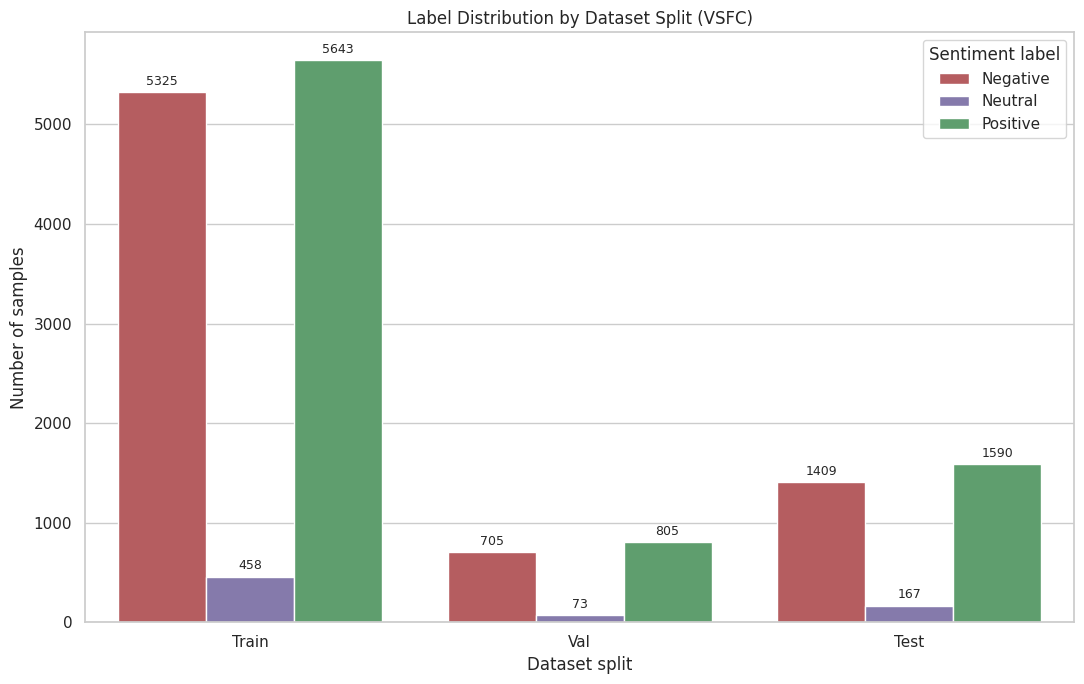

In [11]:
def main() -> None:
    root_path = os.path.join(os.path.expanduser("~"), "sentiment_analysis")
    dataset_path = os.path.join(root_path, "datasets", "vsfc")
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(
            "datasets/vsfc was not found. Please generate/download dataset first."
        )

    dataset = load_from_disk(dataset_path)
    label_df = build_label_dataframe(dataset)

    root_path = os.path.join(os.path.expanduser("~"), "sentiment_analysis")
    output_dir = os.path.join(root_path, "reports", "figure", "01_eda")
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, "label_distribution.png")

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(11, 7))

    ax = sns.barplot(
        data=label_df,
        x="split",
        y="count",
        hue="label",
        hue_order=["Negative", "Neutral", "Positive"],
        palette={
            "Negative": "#C44E52",
            "Neutral": "#8172B3",
            "Positive": "#55A868",
        },
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

    ax.set_title("Label Distribution by Dataset Split (VSFC)")
    ax.set_xlabel("Dataset split")
    ax.set_ylabel("Number of samples")
    ax.legend(title="Sentiment label")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

    print("=== Label distribution by split ===")
    print(label_df.pivot(index="split", columns="label", values="count").fillna(0).astype(int))
    print(f"\nSaved figure to: {output_path}")


if __name__ == "__main__":
    main()
